# Image Quality Assessment — MobileNetV2 Transfer Learning
Notebook ini menggunakan **MobileNetV2 pretrained ImageNet** untuk klasifikasi IQA.  
Bandingkan dengan `IQA_CNN_Model.ipynb` (CNN scratch, ~69% val acc).  
Target: **>85% accuracy, loss <0.2**

**Strategy:** 2-phase training
- Phase 1: Freeze backbone, train head saja
- Phase 2: Unfreeze top 30 layer backbone, fine-tune dengan LR kecil

## 1. Setup & Import

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Memory growth enabled")

tf.keras.mixed_precision.set_global_policy("float32")
tf.config.optimizer.set_jit(False)
print("Policy: float32 | XLA: OFF")

I0000 00:00:1782043441.598551    2003 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled
Policy: float32 | XLA: OFF


## 2. Data Preparation

In [2]:
BASE_DIR    = 'data'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASS_NAMES = ['Blur', 'Lowlight', 'Normal']
os.makedirs('model', exist_ok=True)

def get_file_paths_and_labels(split='train'):
    paths, labels = [], []
    for idx, cls in enumerate(CLASS_NAMES):
        folder = os.path.join(BASE_DIR, cls, split)
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(folder, fname))
                labels.append(idx)
    return paths, labels

train_paths, train_labels = get_file_paths_and_labels('train')
val_paths,   val_labels   = get_file_paths_and_labels('valid')
test_paths,  test_labels  = get_file_paths_and_labels('test')

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
from collections import Counter
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {Counter(train_labels)[i]}")

Train: 1640 | Val: 205 | Test: 205
  Blur: 560
  Lowlight: 400
  Normal: 680


## 3. Data Pipeline

In [3]:
def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    # resize_with_pad: jaga aspect ratio, padding hitam di sisi kosong
    img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def _blur_kernel():
    k = tf.constant([[1,2,1],[2,4,2],[1,2,1]], dtype=tf.float32) / 16.0
    k = k[:, :, tf.newaxis, tf.newaxis]
    return tf.tile(k, [1, 1, 3, 1])

def _sharpen_kernel():
    k = tf.constant([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=tf.float32)
    k = k[:, :, tf.newaxis, tf.newaxis]
    return tf.tile(k, [1, 1, 3, 1])

def apply_blur(img):
    out = tf.nn.depthwise_conv2d(img[tf.newaxis], _blur_kernel(), strides=[1,1,1,1], padding='SAME')
    return out[0]

def apply_sharpen(img):
    out = tf.nn.depthwise_conv2d(img[tf.newaxis], _sharpen_kernel(), strides=[1,1,1,1], padding='SAME')
    return out[0]

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.3)
    img = tf.image.random_contrast(img, lower=0.6, upper=1.4)
    img = tf.image.random_saturation(img, lower=0.6, upper=1.4)
    img = tf.image.random_hue(img, max_delta=0.08)

    img = tf.cond(
        tf.logical_and(tf.equal(label, 0), tf.random.uniform([]) < 0.4),
        lambda: apply_blur(img), lambda: img
    )
    img = tf.cond(
        tf.logical_and(tf.equal(label, 2), tf.random.uniform([]) < 0.4),
        lambda: apply_sharpen(img), lambda: img
    )

    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=4)
    if training:
        ds = ds.shuffle(buffer_size=512, reshuffle_each_iteration=True)
        ds = ds.map(augment_image, num_parallel_calls=4)
    ds = ds.batch(BATCH_SIZE).prefetch(2)
    return ds

train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds   = create_dataset(val_paths,   val_labels,   training=False)
test_ds  = create_dataset(test_paths,  test_labels,  training=False)

for imgs, lbls in train_ds.take(1):
    print(f"Batch: {imgs.shape} | Range: [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")

I0000 00:00:1782043447.953688    2003 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


Batch: (32, 224, 224, 3) | Range: [-1.00, 1.00]


## 4. Model — MobileNetV2 + Custom Head

In [4]:
base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
print(f"MobileNetV2 layers: {len(base_model.layers)}")

reg = keras.regularizers.l2(1e-4)

inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=reg)(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)
model.summary()

MobileNetV2 layers: 154


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 5. Phase 1 — Train Head (backbone frozen)

In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Gunakan computed weights sebagai baseline, lalu fine-tune manual
# Tujuan: semua kelas dapat perhatian seimbang, bukan ada yang dominan
class_weight_dict = {
    0: 1.2,   # Blur — naikkan sedikit supaya ga mudah dikira Normal
    1: 1.5,   # Lowlight — tetap, kelas terkecil
    2: 1.0,   # Normal — turunkan, biarkan augmentation sharpen yang bantu
}
print(f"Class weights: {class_weight_dict}")

callbacks_p1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'model/best_mobilenet.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
]

print("=" * 50)
print("Phase 1: Training HEAD only (backbone frozen)")
print("=" * 50)

history_p1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=70,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict
)

print(f"\nPhase 1 best val_acc: {max(history_p1.history['val_accuracy']):.4f}")

Class weights: {0: 1.2, 1: 1.5, 2: 1.0}
Phase 1: Training HEAD only (backbone frozen)
Epoch 1/70


I0000 00:00:1782043473.761255    2095 cuda_dnn.cc:461] Loaded cuDNN version 92302


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7145 - loss: 1.3361
Epoch 1: val_loss improved from None to 0.86526, saving model to model/best_mobilenet.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 35s 334ms/step - accuracy: 0.7530 - loss: 1.1301 - val_accuracy: 0.6878 - val_loss: 0.8653 - learning_rate: 0.0010
Epoch 2/70
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.6007 - loss: 1.6011
Epoch 2: val_loss improved from 0.86526 to 0.67635, saving model to model/best_mobilenet.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 33s 295ms/step - accuracy: 0.7073 - loss: 1.0695 - val_accuracy: 0.6927 - val_loss: 0.6764 - learning_rate: 0.0010
Epoch 3/70
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.4779 - loss: 1.5869
Epoch 3: val_loss improved from 0.67635 to 0.53328, saving model to model/best_mobilenet.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 23s 316ms/step - accuracy: 0.6159 - loss: 1.0071 - val_accuracy: 0.8976 - val_loss: 0.5333 - learning_rate: 0.0010
Epoch 4/70
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 262m

## 6. Phase 2 — Fine-tune (unfreeze top backbone layers)

In [6]:
# Unfreeze only top 15 layers — less catastrophic forgetting than 30
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

trainable_count = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Trainable params after unfreeze: {trainable_count:,}")

# 10x lower LR than before — critical to avoid destroying Phase 1 weights
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'model/best_mobilenet.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-8, verbose=1
    ),
]

print("=" * 50)
print("Phase 2: Fine-tuning (top 15 backbone layers)")
print("=" * 50)

history_p2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=70, callbacks=callbacks_p2,
    class_weight=class_weight_dict
)

print(f"\nPhase 2 best val_acc: {max(history_p2.history['val_accuracy']):.4f}")

Trainable params after unfreeze: 1,403,779
Phase 2: Fine-tuning (top 15 backbone layers)
Epoch 1/70
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.7965 - loss: 0.6294
Epoch 1: val_loss improved from None to 0.30803, saving model to model/best_mobilenet.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 32s 350ms/step - accuracy: 0.8774 - loss: 0.4299 - val_accuracy: 0.9171 - val_loss: 0.3080 - learning_rate: 1.0000e-05
Epoch 2/70
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8315 - loss: 0.5175
Epoch 2: val_loss did not improve from 0.30803
52/52 ━━━━━━━━━━━━━━━━━━━━ 37s 301ms/step - accuracy: 0.8939 - loss: 0.3671 - val_accuracy: 0.9073 - val_loss: 0.3117 - learning_rate: 1.0000e-05
Epoch 3/70
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8406 - loss: 0.5091
Epoch 3: val_loss did not improve from 0.30803
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 300ms/step - accuracy: 0.9012 - loss: 0.3601 - val_accuracy: 0.8927 - val_loss: 0.3299 - learning_rate: 1.0000e-05
Epoch 4/70
51/52 ━━━━━━━━━━━━

## 7. Training Curves

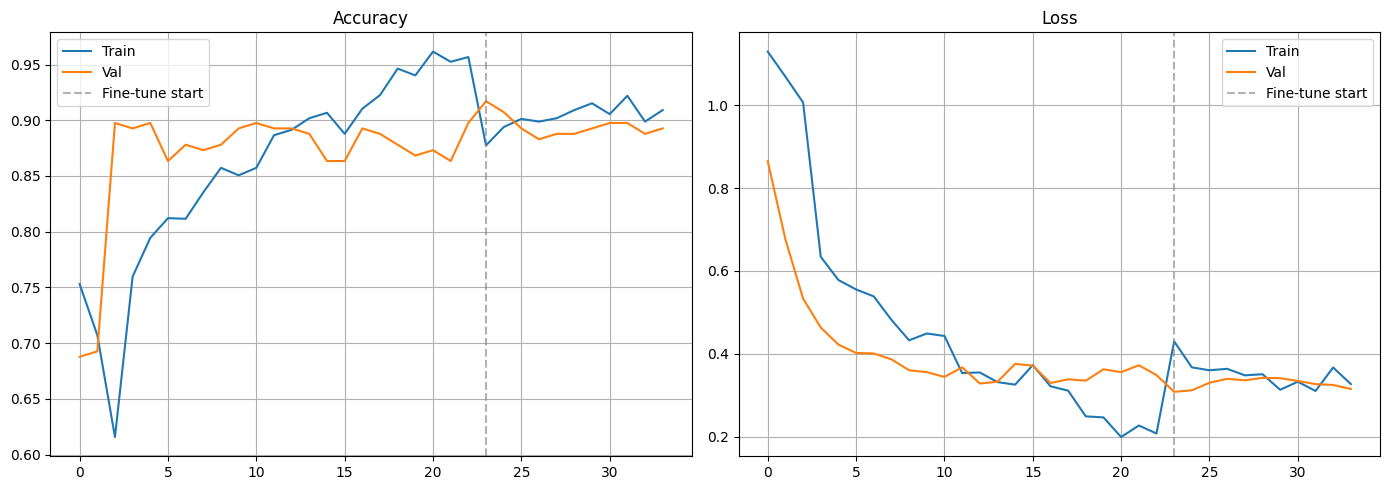

In [10]:
# Gabung history Phase 1 + Phase 2
def merge_history(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

hist = merge_history(history_p1, history_p2)
p1_end = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist['accuracy'], label='Train')
ax1.plot(hist['val_accuracy'], label='Val')
ax1.axvline(p1_end, color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True)

ax2.plot(hist['loss'], label='Train')
ax2.plot(hist['val_loss'], label='Val')
ax2.axvline(p1_end, color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. Evaluasi Test Set

In [11]:
model = keras.models.load_model('model/best_mobilenet.keras')

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.9024 - loss: 0.2884

Test Accuracy : 0.9024 (90.24%)
Test Loss     : 0.2884


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Blur       0.90      0.86      0.88        70
    Lowlight       1.00      0.94      0.97        50
      Normal       0.86      0.92      0.89        85

    accuracy                           0.90       205
   macro avg       0.92      0.90      0.91       205
weighted avg       0.91      0.90      0.90       205



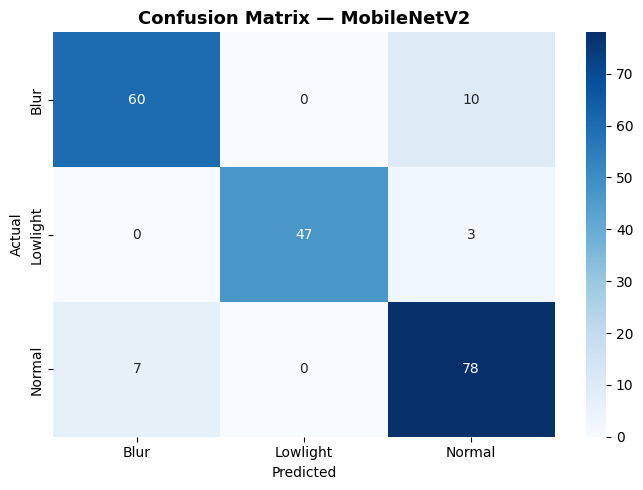

In [12]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels)

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — MobileNetV2', fontsize=13, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

## 9. Export Model

In [13]:
model.save('model/iqa_mobilenet.keras')
print(f"Saved: model/iqa_mobilenet.keras ({os.path.getsize('model/iqa_mobilenet.keras')/1024/1024:.1f} MB)")

# TFLite export
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
try:
    tflite_model = converter.convert()
except Exception:
    converter.optimizations = []
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    tflite_model = converter.convert()

tflite_path = 'model/iqa_mobilenet.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"Saved: {tflite_path} ({os.path.getsize(tflite_path)/1024/1024:.1f} MB)")

Saved: model/iqa_mobilenet.keras (21.3 MB)
INFO:tensorflow:Assets written to: /tmp/tmpmks1v53k/assets


INFO:tensorflow:Assets written to: /tmp/tmpmks1v53k/assets


Saved artifact at '/tmp/tmpmks1v53k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  129364082821072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082831632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082833744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082827056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082829344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082825648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082859296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082861232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082856304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129364082860000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1293640828635

W0000 00:00:1782044734.253147    2003 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782044734.253212    2003 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782044734.253650    2003 reader.cc:83] Reading SavedModel from: /tmp/tmpmks1v53k
I0000 00:00:1782044734.272009    2003 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782044734.272035    2003 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpmks1v53k
I0000 00:00:1782044734.394724    2003 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782044734.428224    2003 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782044735.188792    2003 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpmks1v53k
I0000 00:00:1782044735.396088    2003 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1142457 microseconds.
I0000 00:00:1782044735.636349    20

In [14]:
# Verify TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()
out_det = interpreter.get_output_details()

img = tf.keras.utils.load_img(test_paths[0], target_size=IMG_SIZE)
arr = tf.keras.utils.img_to_array(img)
arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
arr = np.expand_dims(arr, 0).astype(np.float32)

interpreter.set_tensor(in_det[0]['index'], arr)
interpreter.invoke()
pred = interpreter.get_tensor(out_det[0]['index'])
print(f"TFLite test → {CLASS_NAMES[np.argmax(pred)]} ({pred[0].max()*100:.1f}%)")
print("Model siap deployment di AMR!")

/home/almus/.local/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite test → Blur (96.4%)
Model siap deployment di AMR!


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 10. Demo Inference

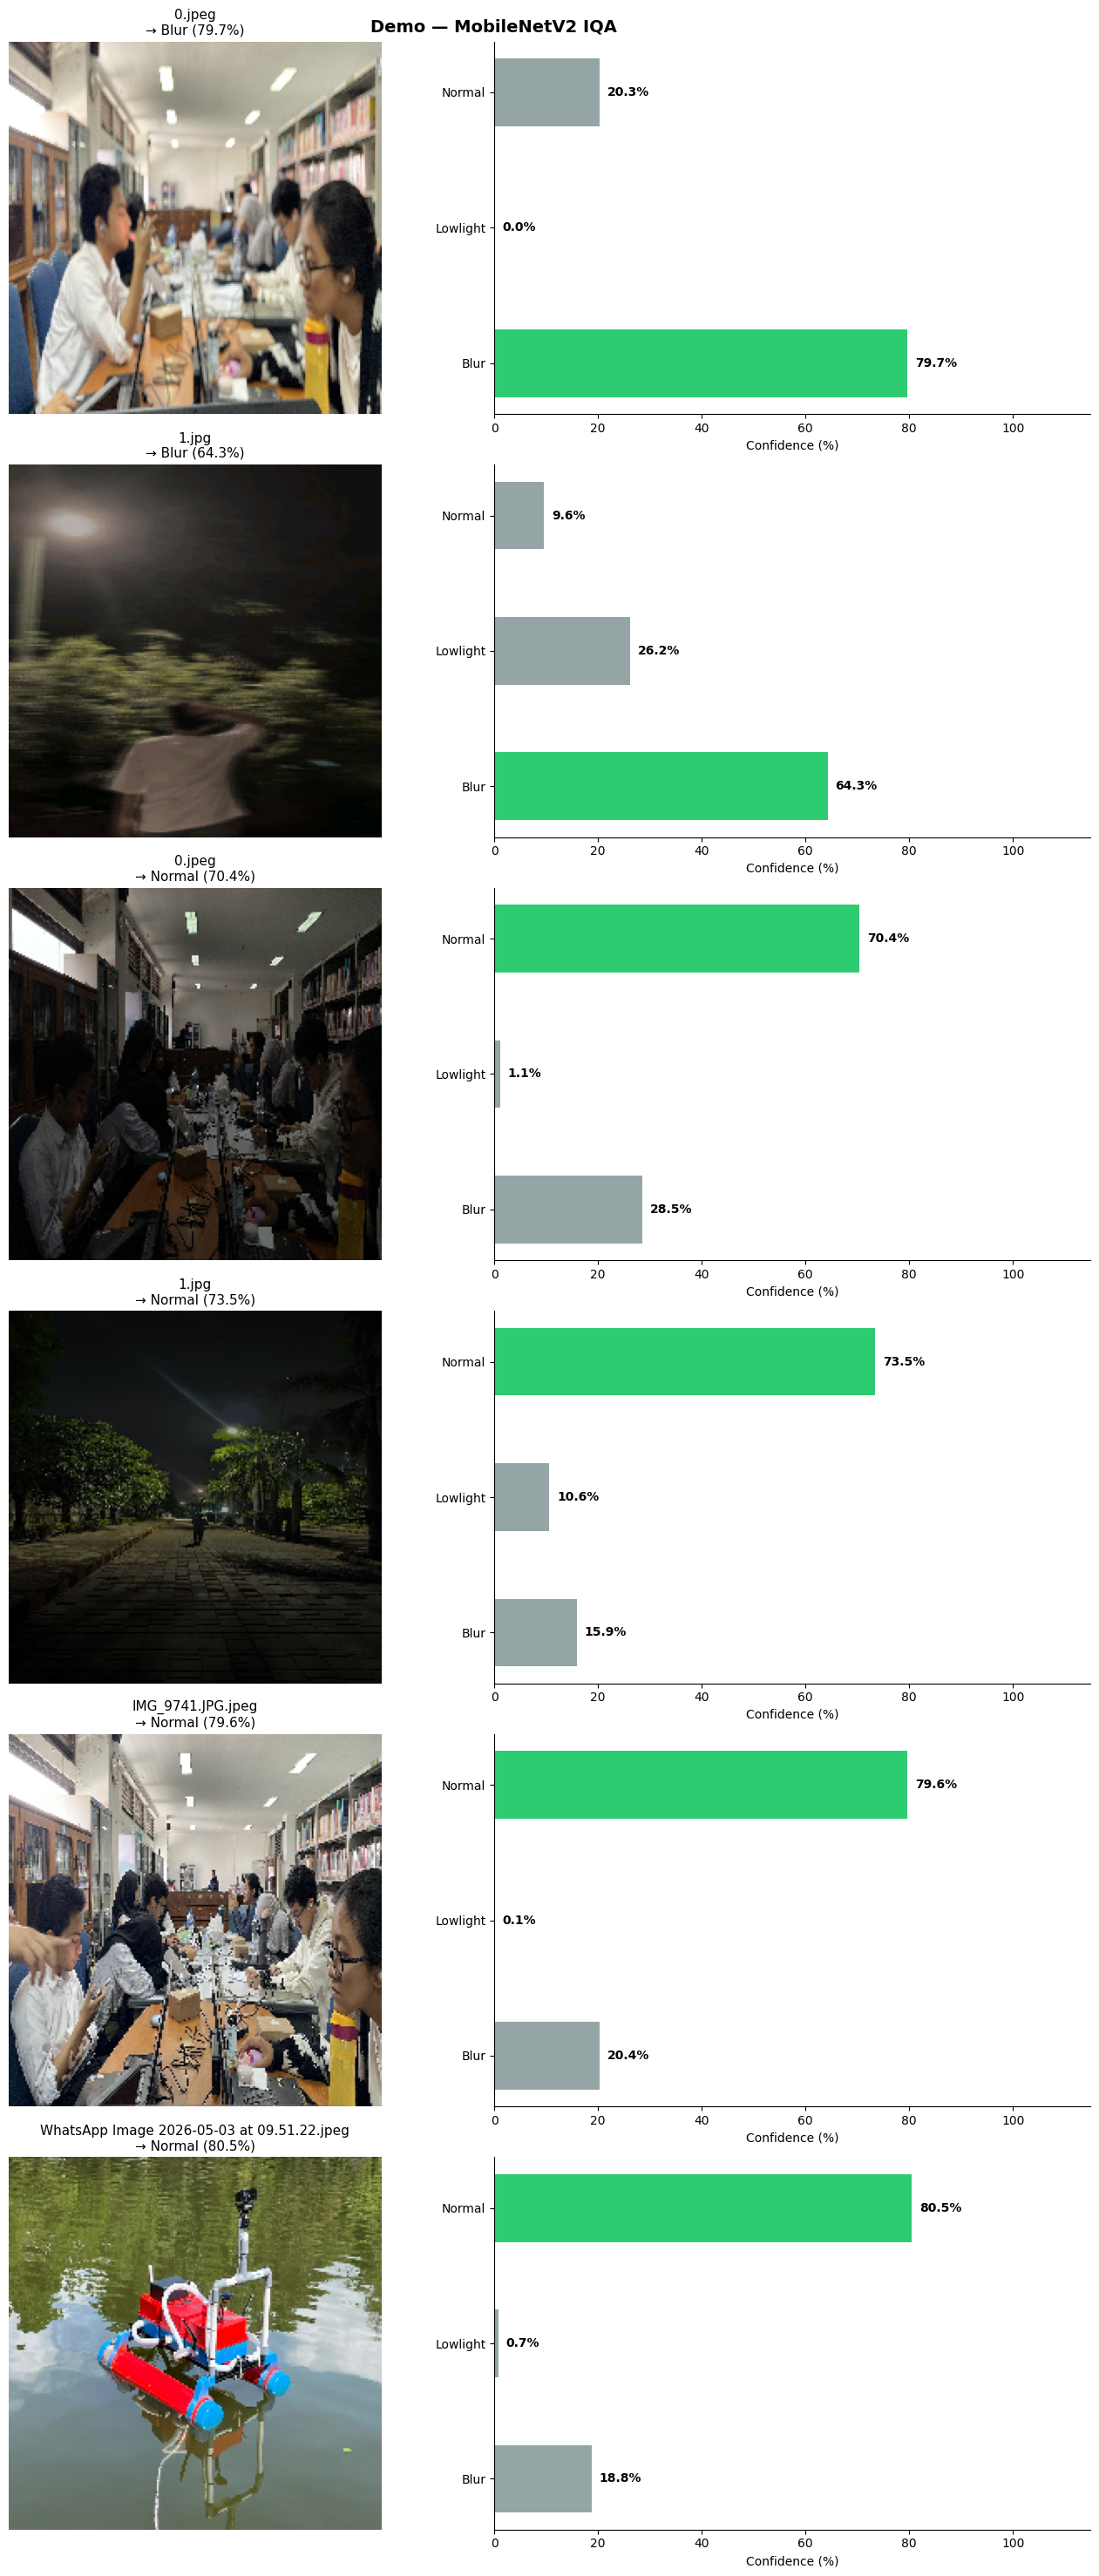

Demo selesai.


In [15]:
from pathlib import Path

demo_root = Path('demo_data')
demo_folders = {'Blur': demo_root/'blur', 'Lowlight': demo_root/'lowlight', 'Normal': demo_root/'normal'}
supported_exts = {'.jpg', '.jpeg', '.png'}

all_images = []
for cls in CLASS_NAMES:
    folder = demo_folders[cls]
    if folder.exists():
        for p in sorted(folder.iterdir()):
            if p.suffix.lower() in supported_exts:
                all_images.append((cls, p))

if not all_images:
    print('Tidak ada gambar di demo_data/')
else:
    n = len(all_images)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5*n))
    if n == 1: axes = [axes]

    for row, (folder_label, img_path) in enumerate(all_images):
        ax_img, ax_bar = axes[row]
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        arr = tf.keras.utils.img_to_array(img)
        arr_pre = tf.keras.applications.mobilenet_v2.preprocess_input(arr.copy())
        probs = model.predict(np.expand_dims(arr_pre, 0), verbose=0)[0]
        pred_idx = int(np.argmax(probs))

        ax_img.imshow(img); ax_img.axis('off')
        ax_img.set_title(f"{img_path.name}\n→ {CLASS_NAMES[pred_idx]} ({probs[pred_idx]*100:.1f}%)", fontsize=11)

        colors = ['#2ecc71' if i==pred_idx else '#95a5a6' for i in range(3)]
        bars = ax_bar.barh(CLASS_NAMES, probs*100, color=colors, height=0.5)
        ax_bar.set_xlim(0, 115); ax_bar.set_xlabel('Confidence (%)')
        for bar, p in zip(bars, probs):
            ax_bar.text(p*100+1.5, bar.get_y()+bar.get_height()/2,
                        f'{p*100:.1f}%', va='center', fontweight='bold')
        ax_bar.spines['top'].set_visible(False); ax_bar.spines['right'].set_visible(False)

    plt.suptitle('Demo — MobileNetV2 IQA', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
print('Demo selesai.')